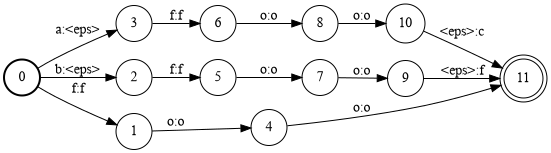

In [58]:
import pynini
from pynini import (
    accep, cross, PdtParentheses, pdt_expand, pdt_compose,
    pdt_replace, pdt_reverse, pdt_shortestpath
)

ascii_table = pynini.SymbolTable()
ascii_table.add_symbol("<eps>")
for i in range(1, 1_000):
    ascii_table.add_symbol(chr(i))

pdt = (
    (cross('a', '')+accep("(")).ques |
    (cross('b', '')+accep("{")).ques 
) + accep("foo") + (
    (accep(")") + cross("", "c")).ques |
    (accep("}") + cross("", "f")).ques
)
pdt.optimize()

parens = PdtParentheses()
parens.add_pair(ord('('), ord(')'))
parens.add_pair(ord('{'), ord('}'))

pdt.set_input_symbols(ascii_table)
pdt.set_output_symbols(ascii_table)

pdt

expanded = None
try:
    expanded = pdt_expand(pdt, parens)
    expanded.optimize()
    expanded.set_input_symbols(ascii_table)
    expanded.set_output_symbols(ascii_table)
except:
    print("nope")
expanded

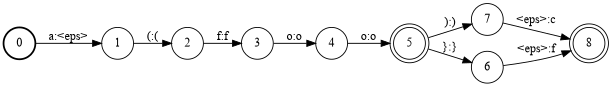

In [45]:
composed = pdt_compose("afoo", pdt, parens, left_pdt=False)
composed.set_input_symbols(ascii_table)
composed.set_output_symbols(ascii_table)
composed.optimize()
# composed.string()
composed

In [40]:
try:
    print(pdt_shortestpath(composed, parens).string())
    
except Exception as e:
    print("Nope")

fooc


In [41]:
try:
    expanded = pdt_expand(composed, parens)
    # expanded.set_input_symbols(ascii_table)
    # expanded.set_output_symbols(ascii_table)
    # expanded.optimize()
    print(expanded.string())
except:
    print("nope")


fooc
